In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [29]:
IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 25
NUM_CLASSES = 6

In [30]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [31]:
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Resizing(IMG_SIZE, IMG_SIZE),
        layers.Rescaling(1./255),

        data_augmentation,

        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(64, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ])

    return model

In [32]:
train_ds = keras.utils.image_dataset_from_directory(
    'dataset_balanceado/train',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_ds = keras.utils.image_dataset_from_directory(
    'dataset_balanceado/val',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = keras.utils.image_dataset_from_directory(
    'dataset_balanceado/test',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
print(f'Classes: {class_names}')


Found 5101 files belonging to 6 classes.
Found 1093 files belonging to 6 classes.
Found 1095 files belonging to 6 classes.
Classes: ['apple_level_0', 'apple_level_1', 'apple_level_2', 'potato_level_0', 'potato_level_1', 'potato_level_2']


In [33]:
model = build_model()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()


Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resizing_2 (Resizing)       (None, 256, 256, 3)       0         
                                                                 
 rescaling_2 (Rescaling)     (None, 256, 256, 3)       0         
                                                                 
 sequential_4 (Sequential)   (None, 256, 256, 3)       0         
                                                                 
 conv2d_9 (Conv2D)           (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 127, 127, 32)      0         
 g2D)                                                            
                                                                 
 conv2d_10 (Conv2D)          (None, 125, 125, 64)      18496     
                                                      

In [34]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)


Epoch 1/25
 34/160 [=====>........................] - ETA: 1:06 - loss: 1.7935 - accuracy: 0.3428

KeyboardInterrupt: 

In [ ]:
scores=model.evaluate(test_ds)

35/35 [==============================] - 5s 131ms/step - loss: 0.4243 - accuracy: 0.8557


In [ ]:
acc=history.history["accuracy"]
val_acc=history.history["val_accuracy"]
loss=history.history["loss"]
val_loss=history.history["val_loss"]

Text(0.5, 1.0, 'Precision del entrenamiento y la validacion')

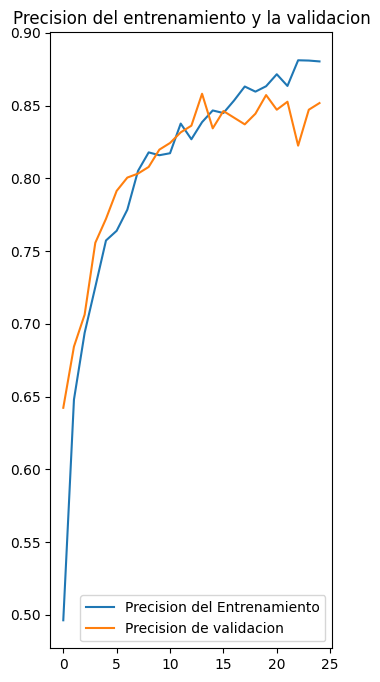

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS),acc,label="Precision del Entrenamiento")
plt.plot(range(EPOCHS),val_acc,label="Precision de validacion")
plt.legend(loc="lower right")
plt.title("Precision del entrenamiento y la validacion")


Primera imagen del batch de prueba
Etiqueta de la primera imagen:  apple_level_0
1/1 [==============================] - 0s 117ms/step
Etiqueta predicha: apple_level_0


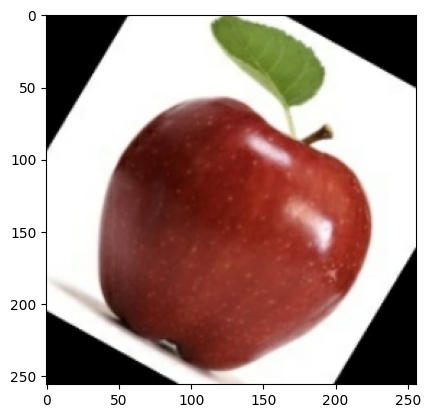

In [ ]:
import numpy as np
for images_batch,labels_batch in test_ds.take(1):
    firts_image=images_batch[0].numpy().astype('uint8')
    firts_label=labels_batch[0].numpy()
    print("Primera imagen del batch de prueba")
    plt.imshow(firts_image)
    print("Etiqueta de la primera imagen: ", class_names[firts_label])
    batch_prediction=model.predict(images_batch)
    print("Etiqueta predicha:",class_names[np.argmax(batch_prediction[0])])

In [ ]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 [==============================] - 0s 20ms/step


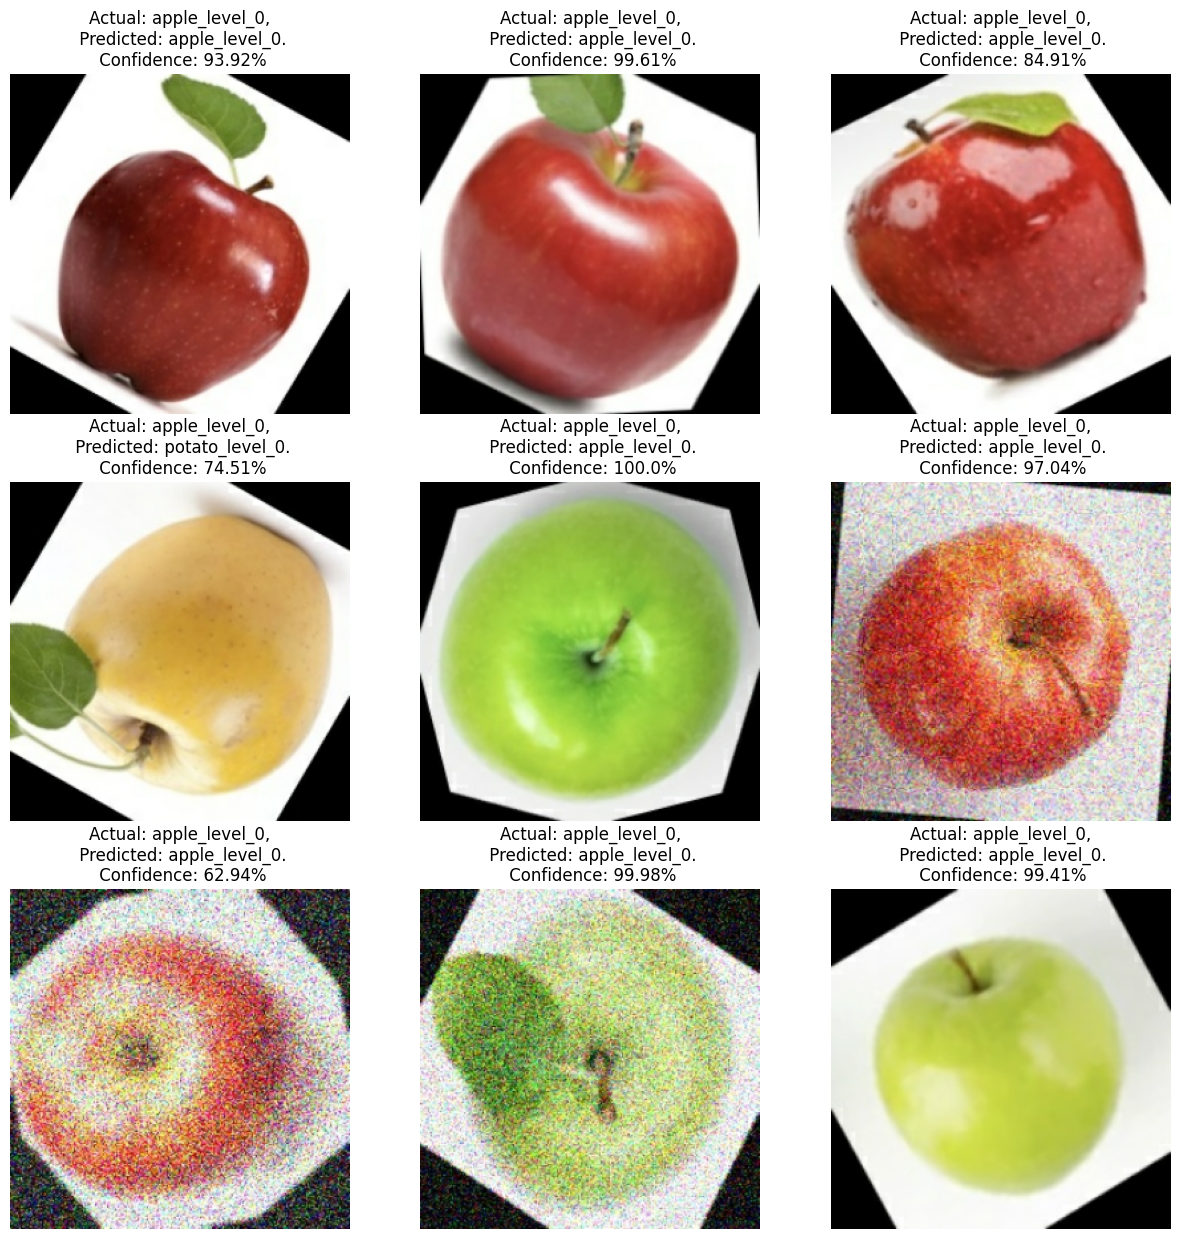

In [ ]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

In [ ]:
model_version=3
model.save(f"./model/{model_version}")


INFO:tensorflow:Assets written to: ./model/3\assets


INFO:tensorflow:Assets written to: ./model/3\assets
